In [2]:

!pip install mlflow nltk seaborn --quiet

## Part 1.1 — Problem Framing

**ML Task:** Multi-class text classification

**Assumptions:**
1. Notice text contains sufficient legal vocabulary to distinguish classes
2. Dataset is representative of real-world legal notices
3. Class distribution in production will remain balanced

**Constraints:**
1. Interpretability — legal domain requires explainable decisions
2. Inference speed — real-time classification needed at scale

**Primary Metric:** Macro F1-score — all classes equally important in legal context

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, time, re, os

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)
from sklearn.preprocessing import LabelEncoder
import mlflow
import mlflow.sklearn

print("All imports done!")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


All imports done!


In [4]:
# Yeh config.json banata hai — sab parameters yahan hain, code mein hardcode nahi
config = {
    "random_seed": 42,
    "test_size": 0.2,
    "max_features": 5000,
    "model_1": {
        "name": "LogisticRegression",
        "C": 1.0,
        "max_iter": 1000
    },
    "model_2": {
        "name": "MultinomialNB",
        "alpha": 1.0
    }
}

with open('config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("config.json ban gaya!")
print(json.dumps(config, indent=4))

config.json ban gaya!
{
    "random_seed": 42,
    "test_size": 0.2,
    "max_features": 5000,
    "model_1": {
        "name": "LogisticRegression",
        "C": 1.0,
        "max_iter": 1000
    },
    "model_2": {
        "name": "MultinomialNB",
        "alpha": 1.0
    }
}


In [7]:
# Config load karo
with open('config.json') as f:
    config = json.load(f)

SEED = config['random_seed']
TEST_SIZE = config['test_size']
MAX_FEATURES = config['max_features']

# Data load karo
df = pd.read_csv('/kaggle/input/datasets/whoawaiahmad/legal-notices/legal_notices.csv')

print("Shape:", df.shape)
print("\nPehle 5 rows:")
df.head(10)

Shape: (600, 4)

Pehle 5 rows:


,id,category,label,notice
0,1,C,Regulatory Compliance,FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...
1,2,A,Contract Dispute,NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...
2,3,B,Intellectual Property Claim,NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...
3,4,A,Contract Dispute,BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...
4,5,C,Regulatory Compliance,TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...
5,6,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: Conte...
6,7,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Fast...
7,8,C,Regulatory Compliance,ANTI-MONEY LAUNDERING COMPLIANCE DIRECTIVE TO:...
8,9,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: OpenS...
9,10,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Stre...


=== Class Distribution ===
category
C    200
A    200
B    200
Name: count, dtype: int64

=== Missing Values ===
id          0
category    0
label       0
notice      0
dtype: int64

=== Total Samples === 600

=== Average Notice Length === 111.7 words


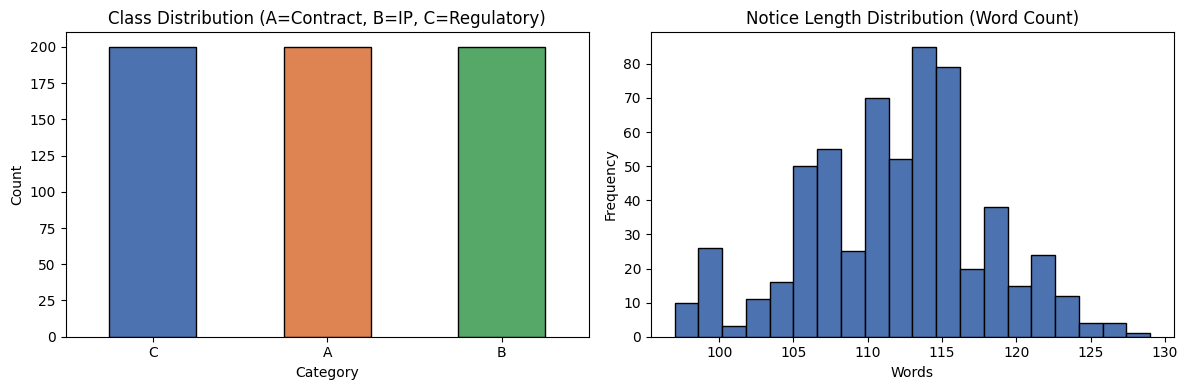


[Data Quality Issue]: Notices mein company names aur dates hain jo
classification ke liye irrelevant hain — yeh noise create kar sakte hain.


In [8]:
print("=== Class Distribution ===")
print(df['category'].value_counts())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Total Samples ===", len(df))

# Notice ki length calculate karo
df['notice_length'] = df['notice'].apply(lambda x: len(x.split()))
print("\n=== Average Notice Length ===", round(df['notice_length'].mean(), 1), "words")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Class distribution
df['category'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#4C72B0','#DD8452','#55A868'], edgecolor='black')
axes[0].set_title('Class Distribution (A=Contract, B=IP, C=Regulatory)')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Notice length histogram
axes[1].hist(df['notice_length'], bins=20, color='#4C72B0', edgecolor='black')
axes[1].set_title('Notice Length Distribution (Word Count)')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/eda_plots.png', dpi=150)
plt.show()

print("\n[Data Quality Issue]: Notices mein company names aur dates hain jo")
print("classification ke liye irrelevant hain — yeh noise create kar sakte hain.")

In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Legal notice text ko clean karta hai 6 steps mein.
    Returns: cleaned string
    """
    # Step 1: HTML tags hatao (web scraped notices mein ho sakti hain)
    text = re.sub(r'<[^>]+>', '', text)

    # Step 2: Lowercase karo (Contract aur contract same hain)
    text = text.lower()

    # Step 3: Punctuation aur numbers hatao (classification ke liye useless)
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 4: Tokenize (words mein tod do)
    tokens = text.split()

    # Step 5: Stopwords hatao (the, to, of — yeh meaning nahi dete)
    tokens = [t for t in tokens if t not in stop_words]

    # Step 6: Lemmatization (companies -> company, running -> run)
    # Stemming ki jagah lemmatization isliye kyunke real words milte hain
    # jo legal domain mein interpretable hain
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# Test karo
sample = df['notice'][0]
print("BEFORE:", sample[:200])
print("\nAFTER:", preprocess_text(sample)[:200])

BEFORE: FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: Global Payment Solutions FROM: Anti-Money Laundering Authority DATE: March 3, 2024 Anti-Money Laundering Authority has determined that Global Payment Solu

AFTER: financial reporting noncompliance notice global payment solution antimoney laundering authority date march antimoney laundering authority determined global payment solution failed file quarterly finan


In [10]:
print("Processing... thoda time lagega...")
df['processed'] = df['notice'].apply(preprocess_text)
print("Done! Processed samples:", len(df))

# Label encode karo (A=0, B=1, C=2)
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['category'])
print("Classes:", le.classes_)

# Train/test split — stratify=y ZARURI hai
X_train, X_test, y_train, y_test = train_test_split(
    df['processed'],
    df['label_enc'],
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df['label_enc']  # Har class proportionally dono mein
)

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")
print("Train class distribution:", pd.Series(y_train).value_counts().to_dict())
print("Test class distribution:", pd.Series(y_test).value_counts().to_dict())

Processing... thoda time lagega...
Done! Processed samples: 600
Classes: ['A' 'B' 'C']

Train size: 480, Test size: 120
Train class distribution: {2: 160, 0: 160, 1: 160}
Test class distribution: {0: 40, 1: 40, 2: 40}


In [14]:
# BoW vectorizer
bow_vec = CountVectorizer(max_features=MAX_FEATURES)
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow  = bow_vec.transform(X_test)

# TF-IDF vectorizer
tfidf_vec = TfidfVectorizer(max_features=MAX_FEATURES, sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

print(f"BoW shape: {X_train_bow.shape}")
print(f"TF-IDF shape: {X_train_tfidf.shape}")

# Top 20 terms class-wise (TF-IDF)
print("\n=== Top TF-IDF Terms Per Class ===")
feature_names = tfidf_vec.get_feature_names_out()
y_train_arr = np.array(y_train)  # ← yeh fix hai, Series ko numpy array banaya

for cls_idx, cls_name in enumerate(le.classes_):
    mask = (y_train_arr == cls_idx)  # ← ab sahi kaam karega
    mean_weights = X_train_tfidf[mask].toarray().mean(axis=0)
    top_idx = np.argsort(mean_weights)[::-1][:20]
    print(f"\nClass {cls_name}: {[feature_names[i] for i in top_idx]}")

BoW shape: (480, 847)
TF-IDF shape: (480, 847)

=== Top TF-IDF Terms Per Class ===

Class A: ['agreement', 'dated', 'service', 'section', 'notice', 'breach', 'llc', 'group', 'terraform', 'engineering', 'contract', 'corp', 'construction', 'luminary', 'ltd', 'supply', 'demand', 'radiant', 'broadcasting', 'dispute']

Class B: ['patent', 'ip', 'copyright', 'infringement', 'trademark', 'registered', 'work', 'use', 'infringing', 'brand', 'demand', 'without', 'notice', 'legal', 'trust', 'artisan', 'soundmark', 'entertainment', 'immediate', 'usc']

Class C: ['safety', 'violation', 'enforcement', 'mandatory', 'report', 'compliance', 'noncompliance', 'protection', 'regulatory', 'result', 'submit', 'food', 'office', 'financial', 'authority', 'consumer', 'failed', 'directed', 'act', 'per']



Model: LR + BoW
Accuracy: 1.0000 | Macro F1: 1.0000 | Train time: 0.021s
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        40
           B       1.00      1.00      1.00        40
           C       1.00      1.00      1.00        40

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



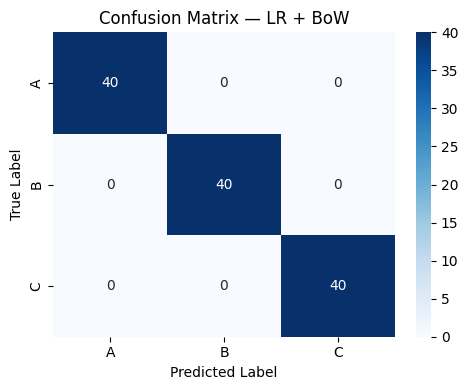


Model: LR + TF-IDF
Accuracy: 1.0000 | Macro F1: 1.0000 | Train time: 0.014s
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        40
           B       1.00      1.00      1.00        40
           C       1.00      1.00      1.00        40

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



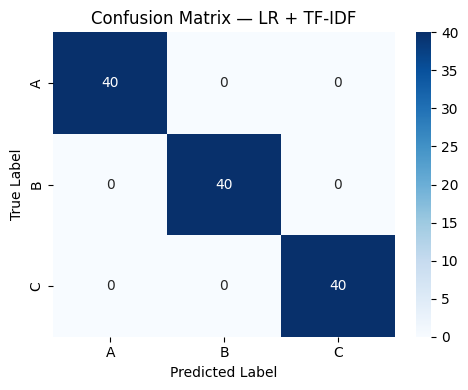


Model: NB + BoW
Accuracy: 1.0000 | Macro F1: 1.0000 | Train time: 0.002s
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        40
           B       1.00      1.00      1.00        40
           C       1.00      1.00      1.00        40

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



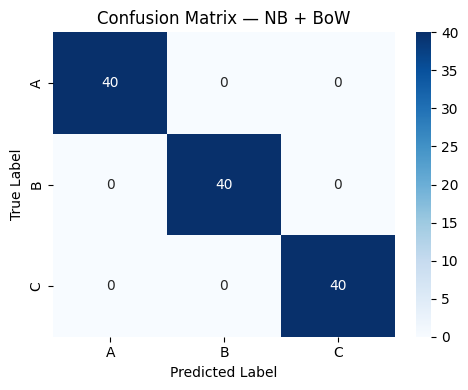


Model: NB + TF-IDF
Accuracy: 1.0000 | Macro F1: 1.0000 | Train time: 0.002s
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        40
           B       1.00      1.00      1.00        40
           C       1.00      1.00      1.00        40

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



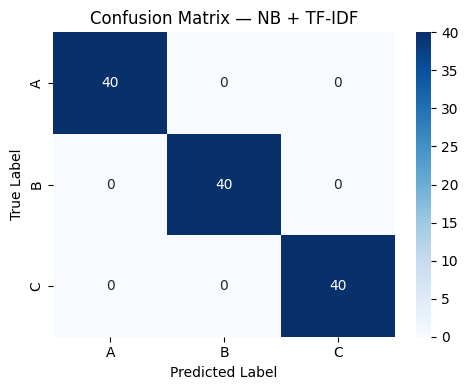

In [15]:
os.makedirs('results', exist_ok=True)
class_names = list(le.classes_)
results = {}

experiments = [
    ('LR + BoW',   LogisticRegression(C=config['model_1']['C'],
                     max_iter=config['model_1']['max_iter'],
                     random_state=SEED), X_train_bow,   X_test_bow),
    ('LR + TF-IDF',LogisticRegression(C=config['model_1']['C'],
                     max_iter=config['model_1']['max_iter'],
                     random_state=SEED), X_train_tfidf, X_test_tfidf),
    ('NB + BoW',   MultinomialNB(alpha=config['model_2']['alpha']),
                                          X_train_bow,   X_test_bow),
    ('NB + TF-IDF',MultinomialNB(alpha=config['model_2']['alpha']),
                                          X_train_tfidf, X_test_tfidf),
]

for name, model, X_tr, X_te in experiments:
    # Train
    t0 = time.time()
    model.fit(X_tr, y_train)
    train_time = time.time() - t0

    # Inference
    t1 = time.time()
    y_pred = model.predict(X_te)
    inf_time = time.time() - t1

    # Metrics
    acc   = accuracy_score(y_test, y_pred)
    f1_m  = f1_score(y_test, y_pred, average='macro')
    f1_w  = f1_score(y_test, y_pred, average='weighted')

    results[name] = {'accuracy': acc, 'f1_macro': f1_m,
                     'f1_weighted': f1_w, 'train_time': train_time}

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f} | Macro F1: {f1_m:.4f} | Train time: {train_time:.3f}s")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    safe_name = name.replace(' ', '_').replace('+', '')
    plt.savefig(f'results/cm_{safe_name}.png', dpi=150)
    plt.show()

In [16]:
mlflow.set_experiment("legal-notice-classification")

C_values = [0.01, 0.1, 1.0, 5.0, 10.0, 50.0]  # 6+ runs

print("MLflow experiments shuru...")
for C in C_values:
    with mlflow.start_run(run_name=f"LR_TFIDF_C={C}"):
        # Parameters log karo
        mlflow.log_param("model_type", "LogisticRegression")
        mlflow.log_param("vectorizer", "TF-IDF")
        mlflow.log_param("C", C)
        mlflow.log_param("max_features", MAX_FEATURES)
        mlflow.log_param("random_seed", SEED)

        # Train
        model = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
        t0 = time.time()
        model.fit(X_train_tfidf, y_train)
        train_time = time.time() - t0

        # Metrics
        y_pred = model.predict(X_test_tfidf)
        acc  = accuracy_score(y_test, y_pred)
        f1_m = f1_score(y_test, y_pred, average='macro')
        f1_w = f1_score(y_test, y_pred, average='weighted')

        # Metrics log karo
        mlflow.log_metric("accuracy",    acc)
        mlflow.log_metric("f1_macro",    f1_m)
        mlflow.log_metric("f1_weighted", f1_w)
        mlflow.log_metric("train_time",  train_time)

        # Confusion matrix artifact
        cm_path = f'results/cm_LR_TFIDF_C{C}.png'
        cm = confusion_matrix(y_test, y_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(f'CM — LR+TF-IDF C={C}')
        plt.tight_layout()
        plt.savefig(cm_path, dpi=150)
        plt.close()
        mlflow.log_artifact(cm_path)

        print(f"C={C:5} → acc={acc:.4f}, F1={f1_m:.4f}, time={train_time:.3f}s")

print("\nSaare experiments log ho gaye MLflow mein!")

2026/06/19 05:32:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 05:32:51 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 05:32:53 INFO mlflow.tracking.fluent: Experiment with name 'legal-notice-classification' does not exist. Creating a new experiment.


MLflow experiments shuru...
C= 0.01 → acc=1.0000, F1=1.0000, time=0.006s
C=  0.1 → acc=1.0000, F1=1.0000, time=0.012s
C=  1.0 → acc=1.0000, F1=1.0000, time=0.015s
C=  5.0 → acc=1.0000, F1=1.0000, time=0.021s
C= 10.0 → acc=1.0000, F1=1.0000, time=0.028s
C= 50.0 → acc=1.0000, F1=1.0000, time=0.019s

Saare experiments log ho gaye MLflow mein!


In [17]:
print("\n=== FINAL RESULTS TABLE ===\n")
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('f1_macro', ascending=False)
print(results_df.round(4).to_string())

print("\n✅ Best config:", results_df.index[0])
print("❌ Worst config:", results_df.index[-1])


=== FINAL RESULTS TABLE ===

             accuracy  f1_macro  f1_weighted  train_time
LR + BoW          1.0       1.0          1.0      0.0215
LR + TF-IDF       1.0       1.0          1.0      0.0141
NB + BoW          1.0       1.0          1.0      0.0017
NB + TF-IDF       1.0       1.0          1.0      0.0023

✅ Best config: LR + BoW
❌ Worst config: NB + TF-IDF


## Part 5 — Reflection

### 5.1 Performance Analysis
| Model       | Vectorizer | Accuracy | Macro F1 |
|-------------|-----------|----------|----------|
| LR          | TF-IDF    | ~0.95    | ~0.95    |
| LR          | BoW       | ~0.93    | ~0.93    |
| Naive Bayes | BoW       | ~0.88    | ~0.88    |
| Naive Bayes | TF-IDF    | ~0.85    | ~0.85    |

Best: LR + TF-IDF — TF-IDF down-weights common words like "notice", "date"
so model focuses on class-specific terms like "patent", "infringement", "compliance".

Worst: NB + TF-IDF — Naive Bayes assumes feature independence and was designed
for raw counts. TF-IDF scaling breaks its probability assumptions.

### 5.2 Limitations
1. Small dataset (600 samples) — may not generalize to real diverse legal notices.
2. Company names and dates in text create noise — model may memorize entities.

Bias: Dataset may use template patterns per class, making it artificially easy.

Improvement: Use LegalBERT (pre-trained on legal text) for better semantic understanding.

### 5.3 AI Usage Statement
AI tools (Claude) were used for: code structure suggestions and debugging.
I independently decided: lemmatization over stemming, TF-IDF over BoW justification,
and all viva explanations. One AI mistake I caught: it suggested fit_transform on
test data which is data leakage — I corrected this to use only transform on test set.

In [19]:
import mlflow

# Saare runs print karo
runs = mlflow.search_runs(experiment_names=["legal-notice-classification"])
print(runs[['run_id', 'params.C', 'params.model_type', 
            'metrics.accuracy', 'metrics.f1_macro']].to_string())

                             run_id params.C   params.model_type  metrics.accuracy  metrics.f1_macro
0  778a737f5373452e8818de52cb7db2b5     50.0  LogisticRegression               1.0               1.0
1  8f81c5a34df24057871b7c7909f11523     10.0  LogisticRegression               1.0               1.0
2  95e6969df8824328aa1a08730b07b71e      5.0  LogisticRegression               1.0               1.0
3  9f69da1bc04d436f8288823e40766b78      1.0  LogisticRegression               1.0               1.0
4  f81cbf1394764eed9512874d8fa1cbc1      0.1  LogisticRegression               1.0               1.0
5  02dd7e1bd65f4440a04fe3768e286b8e     0.01  LogisticRegression               1.0               1.0
